In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
checkpoint_dir = Path("data") / "ch07_checkpoints"

In [3]:
batches, train_losses, val_losses, created_at = [], [], [], []

json_files = sorted(
    checkpoint_dir.glob("*.json"),
    key=lambda x: x.stat().st_ctime,
    #key=lambda x: int(x.name.split("-")[1]),
    reverse=False,
)

for f in json_files:
    #print(f"---> file: {f}")
    data = json.loads(f.read_text())

    batch = f.name.replace("checkpoint_", "").replace(".json", "")
    batches.append(int(batch))
    train_losses.append(data['train_loss'])
    val_losses.append(data['validation_loss'])
    created_at.append(data['created_at'])

In [4]:
df = pd.DataFrame({
    "batches": batches,
    "train_loss": train_losses,
    "val_loss": val_losses,
    "created_at": created_at,
})

df = df.sort_values(by='batches', ascending=True)

print(df.nsmallest(5, 'train_loss'))

df.to_csv(checkpoint_dir / "trainning.tsv", index=False, sep='\t')

pd.concat((df.head(10), df.tail(20)))

    batches  train_loss  val_loss                 created_at
61       19    3.109743  4.158888  2025-09-04T23:56:23+08:00
55       11    3.153672  4.197776  2025-09-04T21:48:07+08:00
51       10    3.184180  4.234122  2025-09-04T21:31:52+08:00
40        8    3.207606  4.255957  2025-09-04T20:59:48+08:00
17        4    3.225596  4.272121  2025-09-04T19:55:51+08:00


,batches,train_loss,val_loss,created_at
29,1,3.419788,4.472746,2025-09-04T18:04:04+08:00
22,2,3.484307,4.529928,2025-09-04T18:23:50+08:00
34,3,3.484949,4.539408,2025-09-04T19:39:52+08:00
17,4,3.225596,4.272121,2025-09-04T19:55:51+08:00
54,5,3.322285,4.371468,2025-09-04T20:11:49+08:00
50,6,3.491122,4.545193,2025-09-04T20:27:48+08:00
14,7,3.334740,4.394372,2025-09-04T20:43:49+08:00
40,8,3.207606,4.255957,2025-09-04T20:59:48+08:00
6,9,3.302789,4.351779,2025-09-04T21:15:50+08:00
51,10,3.184180,4.234122,2025-09-04T21:31:52+08:00


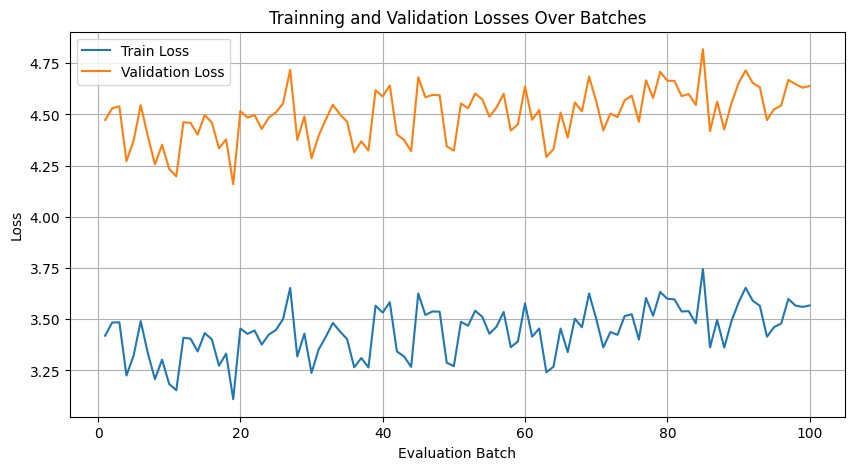

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(df['batches'], df['train_loss'], label="Train Loss")
plt.plot(df['batches'], df['val_loss'], label="Validation Loss")
plt.xlabel("Evaluation Batch")
plt.ylabel("Loss")
plt.title("Trainning and Validation Losses Over Batches")
plt.legend()
plt.grid()
#plt.show()
plt.savefig(checkpoint_dir / "trainning.pdf")